## 🎯 Goal of this notebook

We are trying to answer:

- What does my data actually look like, and what patterns exist inside it?

- Not modeling. Not cleaning deeply yet. Just understanding.

### 1. Import libraries 





In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#for making nicer plots
sns.set_style("whitegrid")
%matplotlib inline

- pandas → for tables, loading and inspecting data.
- numpy → for numeric calculations.
- matplotlib + seaborn → for visualizations.
- %matplotlib inline → ensures plots show in Jupyter notebook.



### 2. Load the data

In [3]:
from sklearn.datasets import fetch_openml 

housing = fetch_openml(name="house_prices", as_frame=True)
df = housing.frame

- fetch_openml is a Python function from scikit-learn.
  
- openml is a repository of datasets for machine learning.
- name = "house_prices" tells it which dataset to get.
- as_frame = True returns a pandas DataFrame
- The object **housing** is not just a DataFrame, it contains:
    - housing.data → feature columns
    - housing.target → the target column SalePrice
    - housing.frame → a single DataFrame with both features and target (what we’ll use)

      

### 3. Inspect the data

In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

- **info → shows data types, missing values, memory usage**


In [6]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


- **describe → numeric summary: min, max, mean, std (helps you notice outliers)**

In [7]:
df.shape

(1460, 81)

- **shape → tells number of rows (houses) and columns (features)**


### 4. Explore the target variable

In [8]:
df["SalePrice"].describe()


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

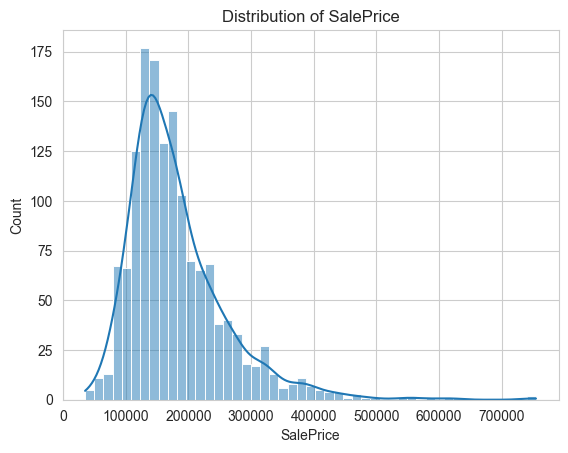

In [9]:
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution of SalePrice")
plt.show()

**Insights**

**1. Right skew (positive skewness):**
- Most houses are in the lower-to-mid price range, and only a few are very expensive.
- Peak is around $120k – $180k
- Long tail extends up to ~$700k
- Meaning:
    - Majority of houses are affordable/moderately priced
    -  A small number of luxury houses are pulling the distribution right

**2. Presence of outliers (high-end homes):** 
- There are a few extreme values.
- Rare homes $400k ()
- $600k (very rare)
- These are not “errors” — they are true high-value properties, but they distort meanand affect regression models (especially linear regression)

**3. Not normally distributed:**

- ML models like Linear Regression assume normality of residuals
- our target is not normal
- So modeling directly on this target is suboptimal.

**4. Mean > Median (implied):**

- Because of right skew: Mean SalePrice is likely higher than median
- Median is a better “typical house price” indicator here

```
SalePrice is heavily right-skewed
↓
A few expensive houses exist
↓
These can generate very large squared errors
↓
Linear Regression minimizes RSS
↓
The optimization may be overly influenced by those expensive houses
↓
Log-transforming SalePrice reduces this effect
↓
Often leads to better-behaved residuals and better predictions

---
### **Find features that affect SalePrice**

**Step 1: Correlation with target**
- This checks which numerical features move together with house price.
- Positive correlation → price increases with feature
- Negative correlation → price decreases with feature
- Near 0 → no relationship

In [10]:
corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
corr.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

**INSIGHTS**

1. OverallQual → strong positive,

    - quality of the house matters the most.
    - A small well-built house can be more expensive than a large low-quality house
    - 
3. GrLivArea → bigger house = higher price
